# Principal Component Analysis (PCA)

## Objective

The objective of this notebook is to transform the engineered feature space into principal components while evaluating whether its dimensionality can be reduced while preserving most of the total variance.

The feature engineering stage produced three variables describing different aspects of the selected asset's market behavior:

- Returns
- Volatility
- Momentum

Although these features provide valuable information, some of their variability may overlap. Principal Component Analysis (PCA) transforms the original features into a new set of orthogonal components that capture the dominant patterns present in the data.

These principal components will subsequently be used as inputs for clustering algorithms in order to identify distinct market regimes.

## Roadmap
1. Project Configuration
2. Load Feature Dataset
3. PCA Workflow Overview
4. Feature Scaling
5. Principal Component Analysis
6. PCA Projection Visualization
7. Final PCA Model
8. Model Persistence
9. Conclusion

-----

## Project Configuration

This section loads the project configuration and required dependencies used throughout the PCA workflow.

Centralizing configuration values ensures consistency across notebooks and allows the analysis to remain reproducible and adaptable to future assets and datasets.

In [2]:
# ==========================================
# Import Libraries and Load Configuration
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
%matplotlib inline

# Absolute path to the project root
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis. "
        "Please select exactly one asset in config.py."
    )

---

## Load Feature Dataset

The engineered feature dataset generated during the feature engineering stage is loaded into memory for preprocessing and dimensionality reduction.

The dataset contains the selected market features—returns, volatility, and momentum—which will be standardized before applying Principal Component Analysis (PCA).

This step prepares the features for dimensionality reduction while preserving the information required for subsequent market regime clustering.

In [3]:
# ==========================================
# Load Feature Dataset
# ==========================================
asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)
feature_path = (f"{PROCESSED_DATA_PATH}/{asset_name}_features.csv" ) 

df = pd.read_csv(feature_path)

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df

,Returns,Volatility,Momentum
Date,,,
2018-01-31,0.011359,0.064866,-0.086472
2018-02-01,-0.102783,0.064014,-0.200817
2018-02-02,-0.037052,0.063907,-0.239214
2018-02-03,0.038973,0.064239,-0.288723
2018-02-04,-0.097865,0.060821,-0.286471
...,...,...,...
2026-08-06,-0.005192,0.015330,-0.012033
2026-08-07,0.009618,0.015067,0.012195
2026-08-08,0.000378,0.014849,0.009219


> ### Dataset Verification

The final feature dataset contains 3,114 observations and three engineered variables: Returns, Volatility, and Momentum.

All features are stored as numerical variables (`float64`), making them directly suitable for mathematical transformations and machine learning algorithms. Furthermore, no missing values remain after the feature engineering stage, confirming that the dataset is fully prepared for dimensionality reduction.

The resulting feature matrix provides a compact representation of the selected asset's market behavior and serves as the input for Principal Component Analysis (PCA).

In [4]:
# ==========================================
# Dataset Verification
# ==========================================
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 3114
Columns: 3
<class 'pandas.DataFrame'>
DatetimeIndex: 3114 entries, 2018-01-31 to 2026-08-10
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Returns     3114 non-null   float64
 1   Volatility  3114 non-null   float64
 2   Momentum    3114 non-null   float64
dtypes: float64(3)
memory usage: 97.3 KB


------

## PCA Workflow Overview

Principal Component Analysis (PCA) is a dimensionality reduction technique used to transform correlated features into a smaller set of uncorrelated components while preserving as much information as possible.

In this project, PCA is applied through the following stages:

1. Feature Standardization
2. Principal Component Extraction
3. Explained Variance Analysis
4. Component Interpretation
5. Projection into PCA Space

The goal is to reduce the dimensionality of the engineered feature set while retaining the majority of the information required for market regime detection.

-----

## Feature Scaling

Principal Component Analysis is sensitive to the scale of the input variables. Features with larger numerical ranges can dominate the resulting principal components, even if they are not inherently more informative.

To ensure that Returns, Volatility, and Momentum contribute equally to the analysis, all features are standardized using StandardScaler. This transformation centers each feature around zero and scales it to unit variance.

In [5]:
# ==========================================
# Import and Apply Standard Sclaer  
# ==========================================
from sklearn.preprocessing import StandardScaler

# Define the features
features = [
    "Returns",
    "Volatility",
    "Momentum"
]

# Apply the StandardScaler
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[features])

In [6]:
# ==========================================
# Convert Back to DataFrame
# ==========================================
scaled_df = pd.DataFrame(
    scaled_features, 
    columns = features, 
    index = df.index
)

scaled_df.head()

,Returns,Volatility,Momentum
Date,,,
2018-01-31,0.311236,2.688065,-0.790643
2018-02-01,-3.164328,2.621446,-1.672945
2018-02-02,-1.162862,2.613112,-1.969215
2018-02-03,1.152054,2.639065,-2.351230
2018-02-04,-3.014558,2.371852,-2.333855


In [7]:
# ==========================================
# Validation
# ==========================================
scaled_df.describe()

,Returns,Volatility,Momentum
count,3.114000e+03,3.114000e+03,3.114000e+03
mean,9.127074e-18,-1.460332e-16,-9.127074e-18
std,1.000161e+00,1.000161e+00,1.000161e+00
min,-1.135251e+01,-1.688016e+00,-3.477211e+00
25%,-4.440257e-01,-6.795806e-01,-5.502369e-01
50%,-1.583259e-02,-2.044538e-01,-7.224188e-02
75%,4.192281e-01,4.570696e-01,4.589425e-01
max,5.673526e+00,4.756846e+00,4.959257e+00


### Interpretation

The standardized feature matrix confirms that all variables have been successfully transformed to a common scale. Following standardization, each feature exhibits a mean approximately equal to zero and a standard deviation approximately equal to one.

This transformation places Returns, Volatility, and Momentum on the same scale so that differences in their original numerical magnitudes do not determine the PCA results.

The presence of extreme standardized values indicates that unusually large market movements and trend events remain represented within the dataset. However, these observations are now expressed relative to each feature's own variability, allowing meaningful comparison across variables.

The standardized dataset is therefore suitable for dimensionality reduction using Principal Component Analysis.

--------

## Principal Component Analysis

After standardizing the feature matrix, Principal Component Analysis (PCA) is applied to identify the dominant patterns present in the data.

PCA transforms the original features into a new set of orthogonal variables called principal components. Each component captures a portion of the total variance present in the dataset, with the first component explaining the largest amount of variability.

The objective is to determine how many components are required to preserve most of the information contained in the engineered feature space.

In [8]:
# ==========================================
# Import and Apply PCA 
# ==========================================
from sklearn.decomposition import PCA 

# Create the pca object
pca = PCA()

# Fit PCA to the scaled features
pca.fit(scaled_features)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [9]:
# ==========================================
# Create the Components
# ==========================================
explained_variance = pd.DataFrame({
    "Principal Component": [ f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))], # It creates a list of labels like ['PC1', 'PC2', 'PC3', ...]
    "Explained Variance Ratio": pca.explained_variance_ratio_, # It pulls the raw percentage of variance (information) that each individual component is responsible for.
    "Cumulative Variance": np.cumsum( pca.explained_variance_ratio_) # It keeps a running tally (a total sum) of the variance as you add more components.
})

explained_variance

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.42403,0.42403
1,PC2,0.33414,0.75817
2,PC3,0.24183,1.00000


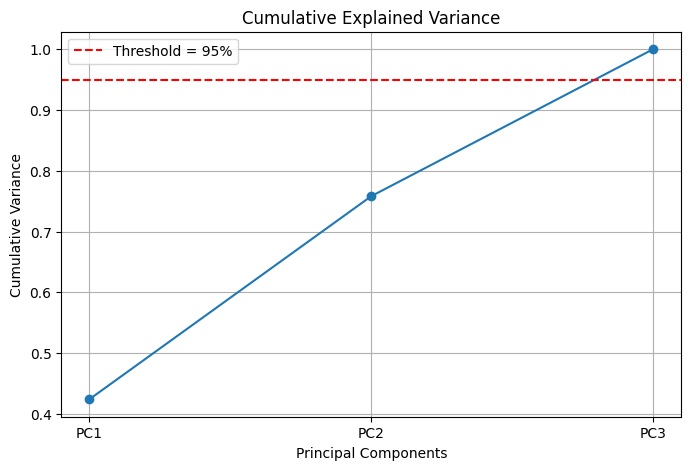

In [10]:
# ==========================================
# Cumulative Variance Chart
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    explained_variance["Principal Component"],
    explained_variance["Cumulative Variance"],
    marker="o"
)

plt.axhline(
    y=PCA_VARIANCE_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Threshold = {PCA_VARIANCE_THRESHOLD:.0%}"
)

plt.ylabel("Cumulative Variance")
plt.xlabel("Principal Components")

plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid(True)

The PCA results indicate that variance is distributed across all three principal components. The first component explains 42.45% of the total variance, while the first two components together explain 75.87%. To preserve at least 95% of the information contained in the feature space, all three principal components must be retained.

This indicates that the variance in the engineered feature space is distributed across all three principal components, meaning that substantial information would be lost if the representation were reduced to only the first two components. Consequently, dimensionality reduction provides limited compression benefits for this feature set, although PCA remains useful for understanding variance structure and preparing the data for clustering.

In [11]:
# ==========================================
# Create Loadings
# ==========================================
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)

loadings

,PC1,PC2,PC3
Returns,0.704865,0.103037,-0.701818
Volatility,-0.043040,0.993783,0.102675
Momentum,0.708034,-0.042166,0.704918


### PCA Loadings Interpretation

The first principal component is primarily influenced by Returns and Momentum, suggesting that it captures the overall direction and strength of market trends. This component explains 42.45% of the total variance.

The second principal component is almost entirely driven by Volatility, indicating that it represents market risk and turbulence. This component explains 33.42% of the variance and provides a distinct view of changing market conditions independent of price direction.

The third principal component contrasts Returns and Momentum, with approximately equal magnitude but opposite signs. This component therefore captures situations in which short-term price returns and recent momentum move in different directions. Such patterns may be associated with changes in market direction or transitional conditions, although the specific economic meaning of the component should be interpreted cautiously.

Overall, the loading structure indicates three distinct dimensions in the standardized feature space: a dimension strongly associated with Returns and Momentum, a dimension dominated by Volatility, and a third dimension contrasting Returns and Momentum.

------

## Final PCA Model

After analyzing the explained variance distribution, the final PCA model is fitted using the variance threshold defined in the project configuration.

Instead of manually selecting the number of components, the model automatically determines the minimum number required to preserve the desired proportion of information.

This approach improves scalability and ensures that the dimensionality reduction process remains adaptable if additional features are incorporated in future versions of the project.

### Component Selection

Rather than specifying a fixed number of principal components, the PCA model uses the variance threshold defined in the project configuration. Components are retained until the cumulative explained variance reaches at least 95% of the total variance.

This approach ensures that the dimensionality reduction process adapts automatically if additional engineered features are introduced in future versions of the project.

In [12]:
# ==========================================
# Apply PCA In Components
# ==========================================
# Create a PCA object with the number of components we want to keep using the TRESHOLD config
pca = PCA(n_components=PCA_VARIANCE_THRESHOLD)

pca_data = pca.fit_transform(scaled_df)

# add components names 
component_names = [ f"PC{i+1}" for i in range(pca.n_components_)]

pca_df = pd.DataFrame(
    pca_data,
    columns= component_names,
    index=scaled_df.index
)

# Number of  components selected
print(
    f"Components selected: "
    f"{pca.n_components_}"
)

pca_df.head()

Components selected: 3


,PC1,PC2,PC3
Date,,,
2018-01-31,-0.456118,2.736761,-0.499772
2018-02-01,-3.527754,2.349646,1.310650
2018-02-02,-2.326402,2.560082,-0.303716
2018-02-03,-0.966295,2.840505,-2.194991
2018-02-04,-3.879392,2.144903,0.714025


### Interpretation

The final PCA model retained all three principal components in order to satisfy the configured 95% variance threshold.

Therefore, the current feature space is not reduced in dimensionality. Instead, the original Returns, Volatility, and Momentum variables are transformed into three orthogonal principal components that preserve 100% of the total variance.

Although PCA does not provide dimensionality compression for the current three-feature configuration, the transformation provides a decorrelated representation of the engineered features and can still be used as the input space for subsequent clustering.

If additional engineered features are introduced in future versions, the configured variance threshold can automatically determine whether a lower-dimensional representation is sufficient.

----

## PCA Projection Visualization

After transforming the original feature space into principal components, it is useful to visualize the observations in the reduced PCA space.

The scatter plot below displays each observation using the first two principal components (PC1 and PC2), which together explain approximately 75.87% of the total variance in the dataset.

The two-dimensional projection is used only for visualization; the final PCA representation retains all components required by the configured variance threshold.

This visualization provides an initial assessment of whether natural groupings or market structures exist within the transformed feature space before applying clustering algorithms for market regime detection.

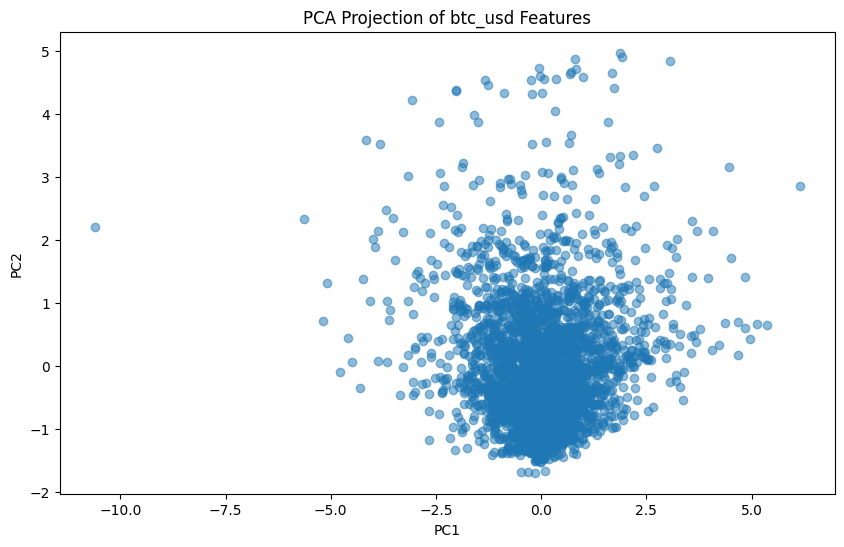

In [13]:
# ==========================================
# PCA Projection Chart
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA Projection of {asset_name} Features")

plt.show()

### Interpretation

The PCA projection shows that most observations are concentrated around the center of the transformed feature space, while a smaller number of observations appear farther from the central region.

These distant observations represent periods with unusual combinations of the engineered market characteristics and may correspond to more extreme market conditions.

The two-dimensional projection does not show clearly separated groups, so distinct market regimes cannot be identified visually at this stage. However, the presence of variation and dispersed observations provides motivation for applying clustering methods to the PCA feature space.

The clustering stage will formally evaluate whether observations can be grouped into distinct market regimes based on their feature characteristics.

-----

## Model Persistence

To ensure reproducibility and support future stages of the market regime detection pipeline, the PCA artifacts are persisted to disk.

The following artifacts are exported:

- PCA-transformed dataset
- Fitted StandardScaler
- Fitted PCA model

Saving these objects allows subsequent notebooks and production pipelines to reuse the exact same transformations without retraining the dimensionality reduction process.

### Export Results
The final step of the PCA stage is to persist all artifacts required for downstream analysis. This includes the transformed PCA dataset used for clustering, as well as the fitted preprocessing objects. Saving these artifacts guarantees reproducibility and allows future data to be transformed using the exact same scaling and PCA configuration.

In [14]:
# ==========================================
# Import New Libraries
# ==========================================
import joblib
from pathlib import Path

In [15]:
# ==========================================
# Create Path's for Imports
# ==========================================
Path(PROCESSED_DATA_PATH).mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Output directory ready: "
    f"{PROCESSED_DATA_PATH}"
)

Path(MODELS_PATH).mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Moldes directory ready: "
    f"{MODELS_PATH}"
)

Output directory ready: ../data/processed
Moldes directory ready: ../outputs/models


In [16]:
# ==========================================
# Paths for the Export's
# ==========================================
pca_output_path = ( 
    f"{PROCESSED_DATA_PATH}/" 
    f"{asset_name}_pca.csv" 
)

scaler_output_path = (
    f"{MODELS_PATH}/"
    f"{asset_name}_scaler.pkl"
)

pca_model_output_path = (
    f"{MODELS_PATH}/"
    f"{asset_name}_pca.pkl"
)

In [17]:
# ==========================================
# Saved and Verify Data
# ==========================================

# Save in Processed 
pca_df.to_csv(pca_output_path)

# Save in models
joblib.dump(
    scaler, 
    scaler_output_path
)

joblib.dump(
    pca,
    pca_model_output_path
)

# Verify where it's saved
print( 
    f"PCA dataset saved to: " 
    f"{pca_output_path}" 
)

print(
    f"Scaler saved to: "
    f"{scaler_output_path}"
)

print(
    f"PCA model saved to: "
    f"{pca_model_output_path}"
)

PCA dataset saved to: ../data/processed/btc_usd_pca.csv
Scaler saved to: ../outputs/models/btc_usd_scaler.pkl
PCA model saved to: ../outputs/models/btc_usd_pca.pkl


In [18]:
# ==========================================
# Export Summary
# ==========================================
print("=" * 50)
print("PCA EXPORT SUMMARY")
print("=" * 50)

print(f"Dataset: {asset_name}")
print(f"Principal Components: {pca.n_components_}")

print(
    f"Cumulative Variance Explained: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

print(f"PCA Dataset: {pca_output_path}")
print(f"Scaler: {scaler_output_path}")
print(f"PCA Model: {pca_model_output_path}")

PCA EXPORT SUMMARY
Dataset: btc_usd
Principal Components: 3
Cumulative Variance Explained: 100.00%
PCA Dataset: ../data/processed/btc_usd_pca.csv
Scaler: ../outputs/models/btc_usd_scaler.pkl
PCA Model: ../outputs/models/btc_usd_pca.pkl


------ 

# Conclusion

In this notebook, Principal Component Analysis (PCA) was applied to the standardized Returns, Volatility, and Momentum features generated during the feature engineering stage.

The explained variance analysis showed that PC1 explains approximately 42.42% of the total variance, while PC1 and PC2 together explain approximately 75.83%. Because the configured variance threshold is 95%, all three principal components are retained in the final PCA representation.

Therefore, PCA does not reduce the dimensionality of the current three-feature dataset. Instead, it transforms the original features into an orthogonal component space while preserving 100% of the total variance.

The loading analysis shows that PC1 is primarily associated with Returns and Momentum, PC2 is strongly dominated by Volatility, and PC3 contrasts Returns and Momentum. This provides a useful representation of the different dimensions of market behavior present in the engineered feature space.

The PCA-transformed dataset, fitted StandardScaler, and fitted PCA model were persisted to disk to ensure reproducibility and support the subsequent clustering stage.

The next step is to apply clustering algorithms to the PCA feature space and evaluate whether distinct market regimes can be identified.